In [3]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("--- MERGE DATA ---")
path = './CIC-IDS2017_Data' 
all_files = glob.glob(os.path.join(path, "*.csv"))

# Đọc và sau đó gộp tất cả các file CSV lại thành 1 DataFrame
df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)

print(f"[+] Đã gộp thành công {len(all_files)} files.")
print(f"[+] Kích thước ban đầu: {df.shape[0]} dòng, {df.shape[1]} cột.")

--- MERGE DATA ---
[+] Đã gộp thành công 8 files.
[+] Kích thước ban đầu: 2830743 dòng, 79 cột.


In [4]:
print("--- DATA CLEANING ---")

# 1. Xóa khoảng trắng thừa ở tên cột
df.columns = df.columns.str.strip()
print("[+] Đã xóa khoảng trắng ở tên cột.")

# 2. Xóa các dòng trùng lặp (Duplicate rows)
initial_rows = len(df)
df.drop_duplicates(inplace=True)
print(f"[+] Đã xóa {initial_rows - len(df)} dòng trùng lặp.")

# 3. Xử lý Inf và NaN bằng cách thay thế bằng Median (Trung vị)
numeric_cols = df.select_dtypes(include=[np.number]).columns
# Biến đổi Inf thành NaN để dễ xử lý đồng loạt
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)
print("[+] Đang tính toán và thay thế giá trị NaN/Inf bằng Median...")
for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
print("[+] Đã xử lý xong Inf và NaN.")

# 4. Xóa các cột có phương sai bằng 0
variances = df[numeric_cols].var()
zero_var_cols = variances[variances == 0].index
df.drop(columns=zero_var_cols, inplace=True)
print(f"[+] Đã xóa {len(zero_var_cols)} cột có phương sai bằng 0: {list(zero_var_cols)}")



--- DATA CLEANING ---
[+] Đã xóa khoảng trắng ở tên cột.
[+] Đã xóa 308381 dòng trùng lặp.
[+] Đang tính toán và thay thế giá trị NaN/Inf bằng Median...
[+] Đã xử lý xong Inf và NaN.
[+] Đã xóa 8 cột có phương sai bằng 0: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [5]:
import pandas as pd
import numpy as np
from pandas.api.types import is_integer_dtype, is_float_dtype

print("--- MEMORY OPTIMIZATION ---")

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"[*] RAM sử dụng ban đầu: {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if is_integer_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min >= np.iinfo(np.int8).min and c_max <= np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min >= np.iinfo(np.int16).min and c_max <= np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min >= np.iinfo(np.int32).min and c_max <= np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)
                
        elif is_float_dtype(col_type):
            c_min = df[col].min()
            c_max = df[col].max()
            if c_min >= np.finfo(np.float32).min and c_max <= np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)
                
        else:
            # Nếu là object hoặc dạng khác, ép về category để tiết kiệm RAM
            df[col] = df[col].astype('category')
        
        print(f"    - {col}: {col_type} -> {df[col].dtype}")

    end_mem = df.memory_usage().sum() / 1024**2
    print(f"[+] RAM sử dụng sau tối ưu: {end_mem:.2f} MB")
    print(f"[+] Đã giảm được {100 * (start_mem - end_mem) / start_mem:.1f}% dung lượng RAM!")
    return df

df = reduce_mem_usage(df)


--- MEMORY OPTIMIZATION ---
[*] RAM sử dụng ban đầu: 1385.57 MB
    - Destination Port: int64 -> int32
    - Flow Duration: int64 -> int32
    - Total Fwd Packets: int64 -> int32
    - Total Backward Packets: int64 -> int32
    - Total Length of Fwd Packets: int64 -> int32
    - Total Length of Bwd Packets: int64 -> int32
    - Fwd Packet Length Max: int64 -> int16
    - Fwd Packet Length Min: int64 -> int16
    - Fwd Packet Length Mean: float64 -> float32
    - Fwd Packet Length Std: float64 -> float32
    - Bwd Packet Length Max: int64 -> int16
    - Bwd Packet Length Min: int64 -> int16
    - Bwd Packet Length Mean: float64 -> float32
    - Bwd Packet Length Std: float64 -> float32
    - Flow Bytes/s: float64 -> float32
    - Flow Packets/s: float64 -> float32
    - Flow IAT Mean: float64 -> float32
    - Flow IAT Std: float64 -> float32
    - Flow IAT Max: int64 -> int32
    - Flow IAT Min: int64 -> int32
    - Fwd IAT Total: int64 -> int32
    - Fwd IAT Mean: float64 -> float32
  

--- EXPLORATORY DATA ANALYSIS (EDA) ---


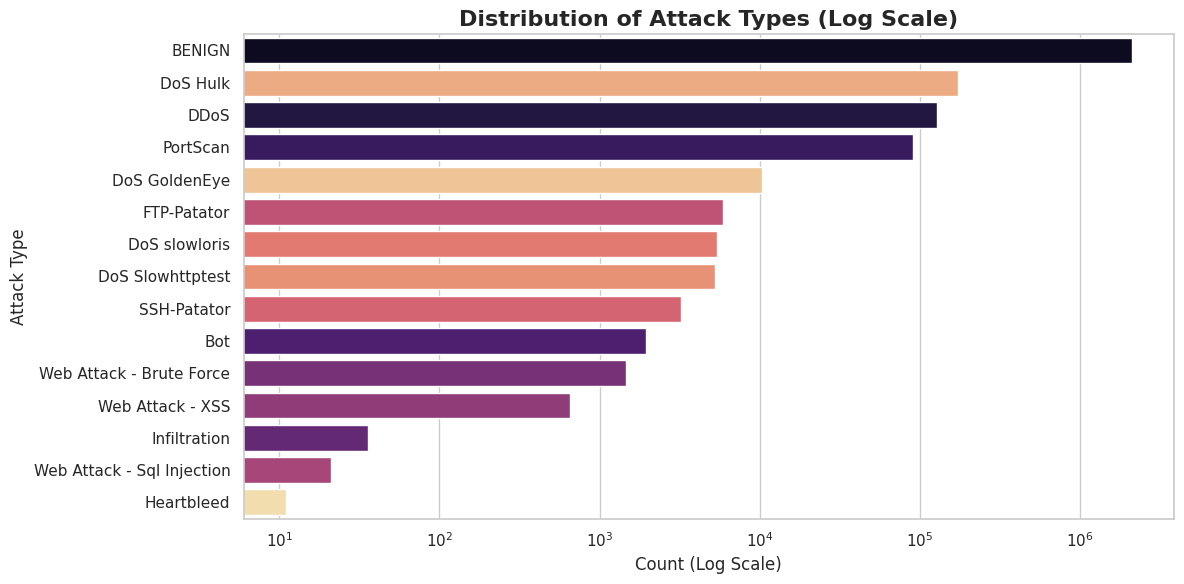

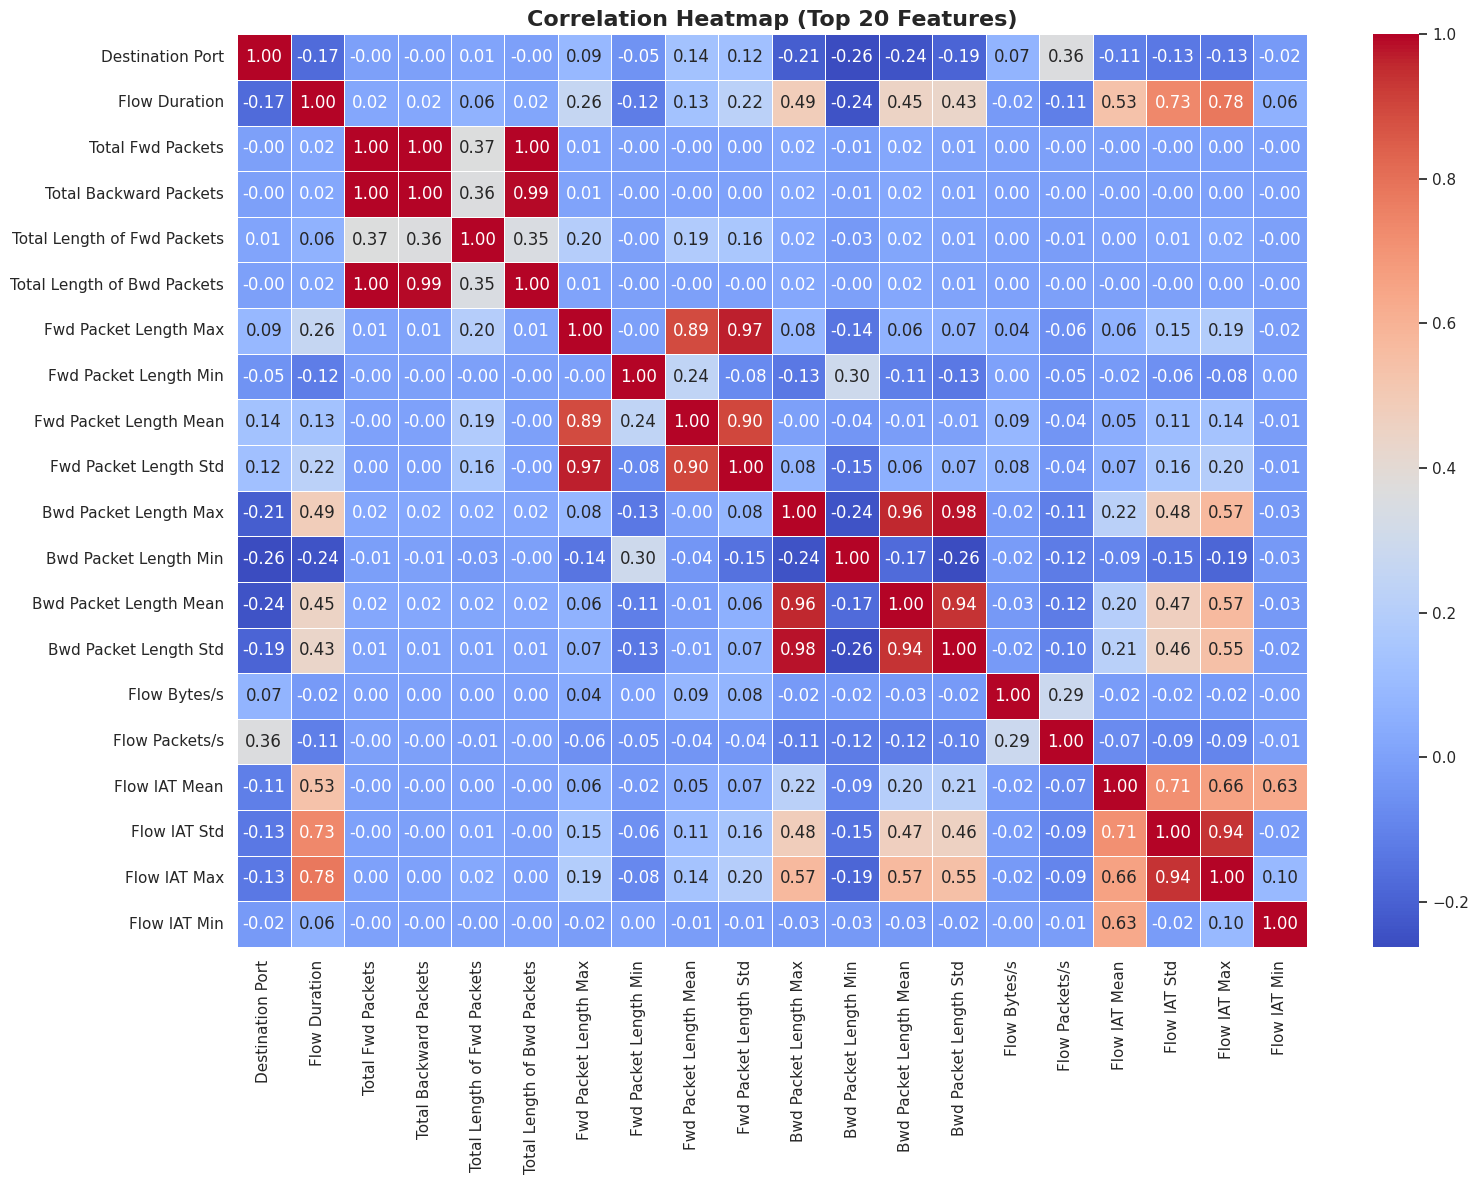

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("--- EXPLORATORY DATA ANALYSIS (EDA) ---")
sns.set_theme(style="whitegrid")

df['Label'] = df['Label'].astype(str).str.replace(r'[^\x00-\x7F]+', '-', regex=True)

plt.rcParams['font.family'] = 'DejaVu Sans'

# Biểu đồ 1: Phân phối các loại tấn công
plt.figure(figsize=(12, 6))
order = df['Label'].value_counts().index

sns.countplot(y="Label", data=df, order=order, hue="Label", palette="magma", legend=False)
plt.title('Distribution of Attack Types (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Count (Log Scale)', fontsize=12)
plt.ylabel('Attack Type', fontsize=12)
plt.xscale('log') 
plt.tight_layout()
plt.show()

# Biểu đồ 2: Correlation Heatmap
plt.figure(figsize=(16, 12))
numeric_features = df.select_dtypes(include=[np.number])
corr_matrix = numeric_features.iloc[:, :20].corr()

sns.heatmap(corr_matrix, cmap='coolwarm', annot=True, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap (Top 20 Features)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print("--- HANDLING CLASS IMBALANCE ---")

# 1. Label Encoding
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))

# 2. Standard Scaling
X = df.drop('Label', axis=1)
y = df['Label']
numeric_cols = X.select_dtypes(include=[np.number]).columns

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[numeric_cols])
X = pd.DataFrame(X_scaled, columns=numeric_cols, dtype=np.float32)

# 3. Data Balancing (SMOTE + UnderSampler)
class_counts = y.value_counts()
majority_class = class_counts.idxmax()
majority_count = class_counts.max()

smote_threshold = int(majority_count * 0.1)

smote_strategy = {
    cls: smote_threshold 
    for cls, count in class_counts.items() 
    if cls != majority_class and count < smote_threshold and count > 5
}
under_strategy = {majority_class: int(majority_count * 0.3)}

smote = SMOTE(sampling_strategy=smote_strategy, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

rus = RandomUnderSampler(sampling_strategy=under_strategy, random_state=42)
X_final, y_final = rus.fit_resample(X_resampled, y_resampled)

# 4. Reconstruct DataFrame
df = pd.concat([X_final, pd.Series(y_final, name='Label')], axis=1)

print(f"[+] Hoàn tất! Kích thước DataFrame hiện tại: {df.shape}")

--- HANDLING CLASS IMBALANCE ---
[+] Hoàn tất! Kích thước DataFrame hiện tại: (3564017, 71)


In [8]:
from sklearn.model_selection import train_test_split

print("--- FEATURE SELECTION & DATA SPLITTING ---")

# 1. Clean and Rename Columns
df.columns = df.columns.str.strip()

rename_dict = {
    'Total Fwd Packets': 'Tot Fwd Pkts',
    'Total Backward Packets': 'Tot Bwd Pkts',
    'Total Length of Fwd Packets': 'TotLen Fwd Pkts',
    'Total Length of Bwd Packets': 'TotLen Bwd Pkts',
    'Fwd Packet Length Mean': 'Fwd Pkt Len Mean',
    'Bwd Packet Length Mean': 'Bwd Pkt Len Mean',
    'Flow Bytes/s': 'Flow Byts/s',
    'Flow Packets/s': 'Flow Pkts/s',
    'Packet Length Mean': 'Pkt Len Mean',
    'Packet Length Std': 'Pkt Len Std',
    'SYN Flag Count': 'SYN Flag Cnt',
    'ACK Flag Count': 'ACK Flag Cnt',
    'FIN Flag Count': 'FIN Flag Cnt',
    'RST Flag Count': 'RST Flag Cnt',
    'PSH Flag Count': 'PSH Flag Cnt',
    'URG Flag Count': 'URG Flag Cnt'
}
df.rename(columns=rename_dict, inplace=True)

# 2. Select Features
selected_features = [
    'Destination Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
    'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Mean',
    'Bwd Pkt Len Mean', 'Flow Byts/s', 'Flow Pkts/s',
    'Pkt Len Mean', 'Pkt Len Std', 'SYN Flag Cnt',
    'ACK Flag Cnt', 'FIN Flag Cnt', 'RST Flag Cnt',
    'PSH Flag Cnt', 'URG Flag Cnt'
]

columns_to_keep = selected_features + ['Label']
df_selected = df[columns_to_keep]

print(f"[+] Features selected successfully! Retained {df_selected.shape[1]} columns.")

# 3. Train/Test Split
X = df_selected.drop('Label', axis=1)
y = df_selected['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\n[*] DATA SPLIT RESULTS:")
print(f"    - Train set: X_train={X_train.shape}, y_train={y_train.shape}")
print(f"    - Test set:  X_test={X_test.shape}, y_test={y_test.shape}")

--- FEATURE SELECTION & DATA SPLITTING ---
[+] Features selected successfully! Retained 19 columns.

[*] DATA SPLIT RESULTS:
    - Train set: X_train=(2851213, 18), y_train=(2851213,)
    - Test set:  X_test=(712804, 18), y_test=(712804,)


--- MODEL IMPLEMENTATION & COMPARISON ---
[*] Đang huấn luyện: Logistic Regression ...

[+] Classification Report - Logistic Regression:
                            precision    recall  f1-score   support

                    BENIGN       0.93      0.81      0.86    125789
                       Bot       0.77      0.73      0.75     41929
                      DDoS       0.84      0.99      0.91     41930
             DoS GoldenEye       0.96      0.88      0.92     41930
                  DoS Hulk       0.98      0.94      0.96     41930
          DoS Slowhttptest       0.91      0.86      0.88     41930
             DoS slowloris       0.82      0.57      0.67     41929
               FTP-Patator       0.97      1.00      0.98     41930
                Heartbleed       1.00      1.00      1.00     41930
              Infiltration       0.99      0.84      0.91     41930
                  PortScan       0.76      0.97      0.85     41929
               SSH-Patator       0.99      0.9

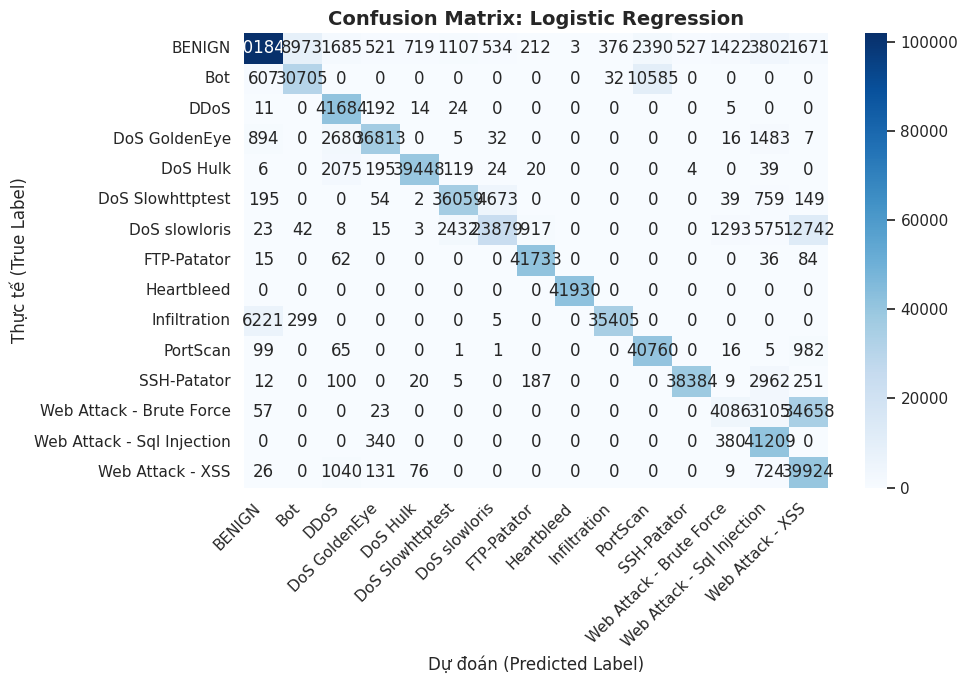

[*] Đang huấn luyện: Support Vector Machine (LinearSVC) ...

[+] Classification Report - Support Vector Machine (LinearSVC):
                            precision    recall  f1-score   support

                    BENIGN       0.85      0.79      0.82    125789
                       Bot       0.78      0.49      0.60     41929
                      DDoS       0.73      0.99      0.84     41930
             DoS GoldenEye       0.94      0.68      0.79     41930
                  DoS Hulk       0.94      0.90      0.92     41930
          DoS Slowhttptest       0.92      0.80      0.86     41930
             DoS slowloris       0.72      0.56      0.63     41929
               FTP-Patator       0.96      1.00      0.98     41930
                Heartbleed       1.00      1.00      1.00     41930
              Infiltration       0.98      0.85      0.91     41930
                  PortScan       0.76      0.99      0.86     41929
               SSH-Patator       0.99      0.91      0.95 

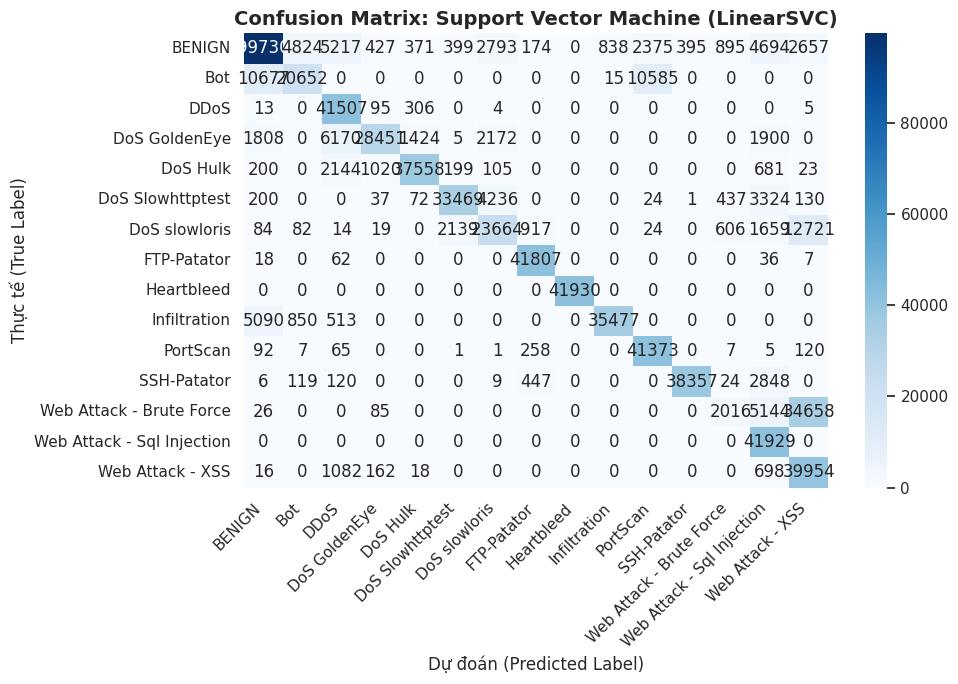

[*] Đang huấn luyện: Naive Bayes ...

[+] Classification Report - Naive Bayes:
                            precision    recall  f1-score   support

                    BENIGN       0.94      0.21      0.35    125789
                       Bot       0.51      1.00      0.68     41929
                      DDoS       0.88      0.45      0.60     41930
             DoS GoldenEye       0.31      0.97      0.47     41930
                  DoS Hulk       0.97      0.42      0.58     41930
          DoS Slowhttptest       0.35      0.14      0.20     41930
             DoS slowloris       0.52      0.57      0.55     41929
               FTP-Patator       0.99      1.00      0.99     41930
                Heartbleed       1.00      1.00      1.00     41930
              Infiltration       0.94      0.90      0.92     41930
                  PortScan       0.31      0.99      0.48     41929
               SSH-Patator       0.99      0.92      0.95     41930
  Web Attack - Brute Force       0.9

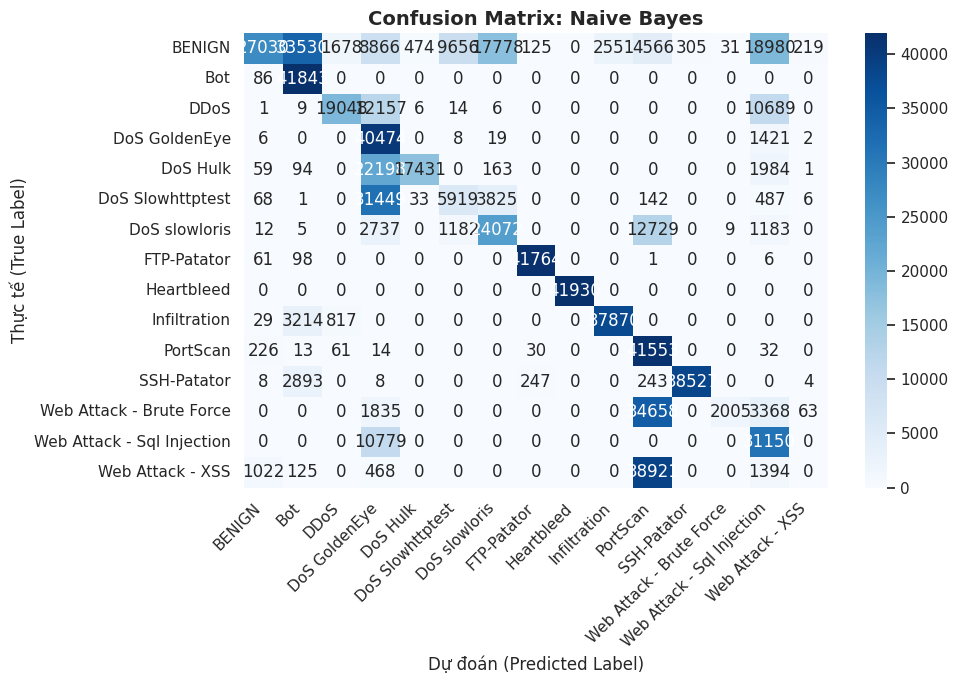

[*] Đang huấn luyện: K-Nearest Neighbors ...

[+] Classification Report - K-Nearest Neighbors:
                            precision    recall  f1-score   support

                    BENIGN       0.99      0.97      0.98    125789
                       Bot       0.98      1.00      0.99     41929
                      DDoS       1.00      1.00      1.00     41930
             DoS GoldenEye       1.00      1.00      1.00     41930
                  DoS Hulk       1.00      0.99      1.00     41930
          DoS Slowhttptest       1.00      1.00      1.00     41930
             DoS slowloris       1.00      1.00      1.00     41929
               FTP-Patator       1.00      1.00      1.00     41930
                Heartbleed       1.00      1.00      1.00     41930
              Infiltration       1.00      1.00      1.00     41930
                  PortScan       0.97      1.00      0.98     41929
               SSH-Patator       1.00      1.00      1.00     41930
  Web Attack - Brute

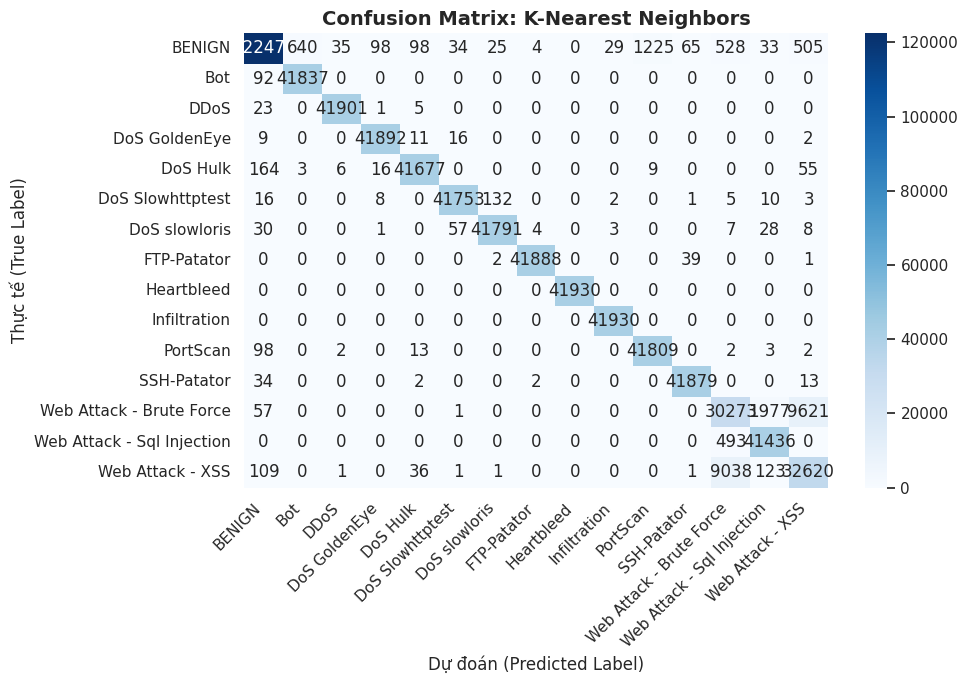

[*] Đang huấn luyện: Random Forest ...

[+] Classification Report - Random Forest:
                            precision    recall  f1-score   support

                    BENIGN       1.00      0.99      0.99    125789
                       Bot       0.98      1.00      0.99     41929
                      DDoS       1.00      1.00      1.00     41930
             DoS GoldenEye       1.00      1.00      1.00     41930
                  DoS Hulk       1.00      0.99      1.00     41930
          DoS Slowhttptest       1.00      1.00      1.00     41930
             DoS slowloris       1.00      1.00      1.00     41929
               FTP-Patator       1.00      1.00      1.00     41930
                Heartbleed       1.00      1.00      1.00     41930
              Infiltration       1.00      1.00      1.00     41930
                  PortScan       1.00      1.00      1.00     41929
               SSH-Patator       1.00      1.00      1.00     41930
  Web Attack - Brute Force      

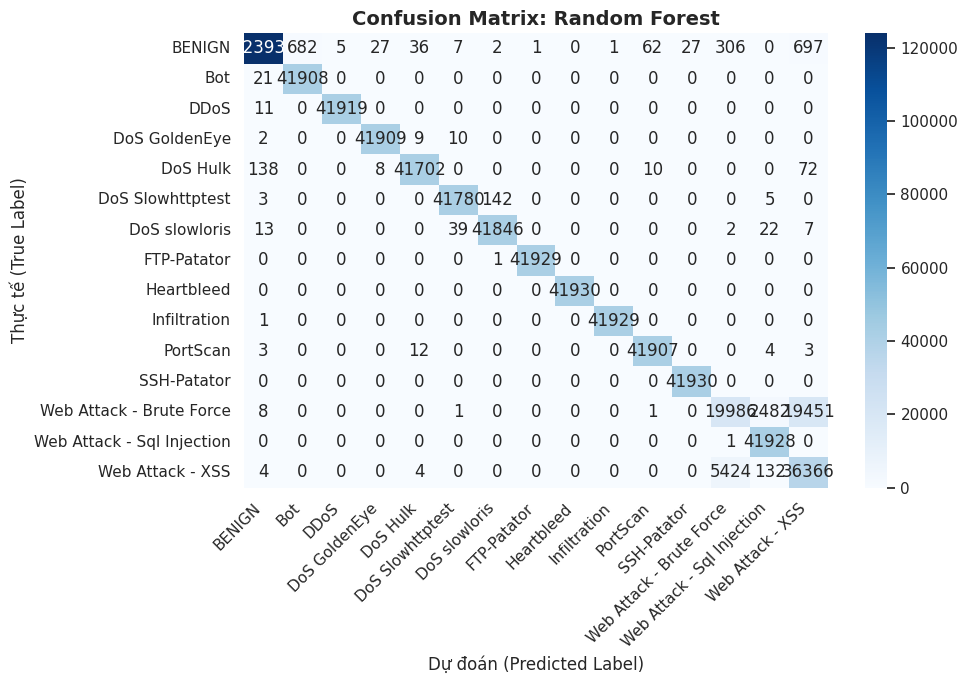

[*] Đang huấn luyện: Support Vector Machine (SVC-RBF, subset) ...

[+] Classification Report - Support Vector Machine (SVC-RBF, subset):
                            precision    recall  f1-score   support

                    BENIGN       0.89      0.82      0.85     17771
                       Bot       0.93      0.84      0.88      5877
                      DDoS       0.79      0.99      0.88      5895
             DoS GoldenEye       0.95      0.88      0.91      5863
                  DoS Hulk       0.99      0.94      0.96      5845
          DoS Slowhttptest       0.90      0.93      0.92      6004
             DoS slowloris       0.92      0.54      0.68      5770
               FTP-Patator       0.92      0.99      0.95      5827
                Heartbleed       1.00      1.00      1.00      5992
              Infiltration       0.98      0.94      0.96      5950
                  PortScan       0.95      0.98      0.96      5877
               SSH-Patator       0.89      0.9

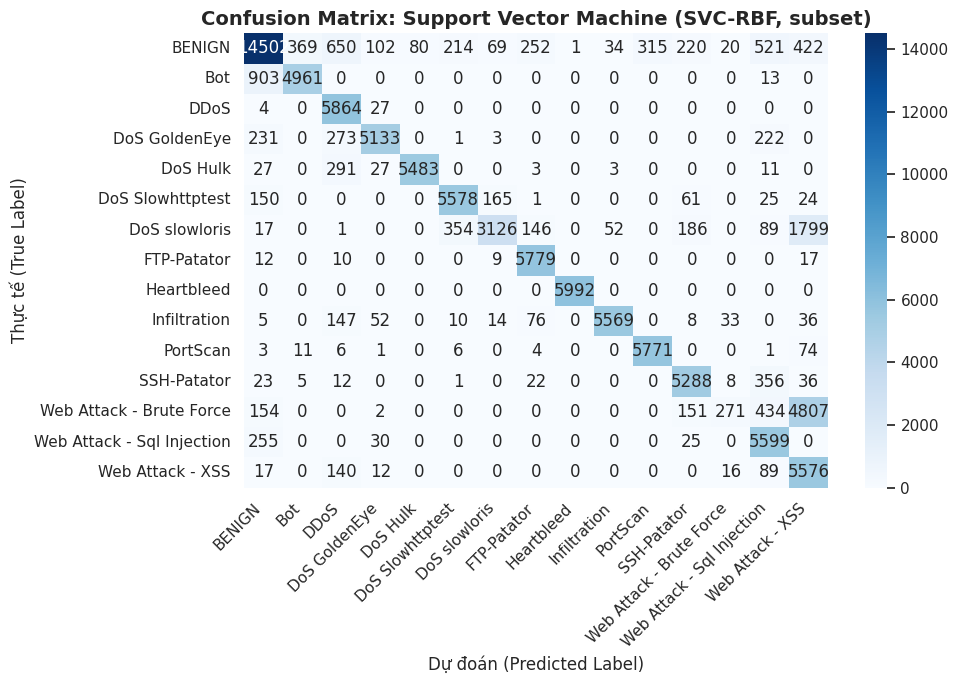


=== Tổng hợp kết quả ===
                                      Model  Accuracy  Precision (macro)  \
0                       Logistic Regression  0.833141           0.844187   
1        Support Vector Machine (LinearSVC)  0.796676           0.811986   
2                               Naive Bayes  0.576057           0.676625   
3                       K-Nearest Neighbors  0.963920           0.959682   
4                             Random Forest  0.958054           0.955533   
5  Support Vector Machine (SVC-RBF, subset)  0.844920           0.873020   

   Recall (macro)  F1 (macro)  
0        0.836269    0.818333  
1        0.797187    0.776249  
2        0.624214    0.560894  
3        0.962627    0.961084  
4        0.954425    0.951396  
5        0.847717    0.826985  


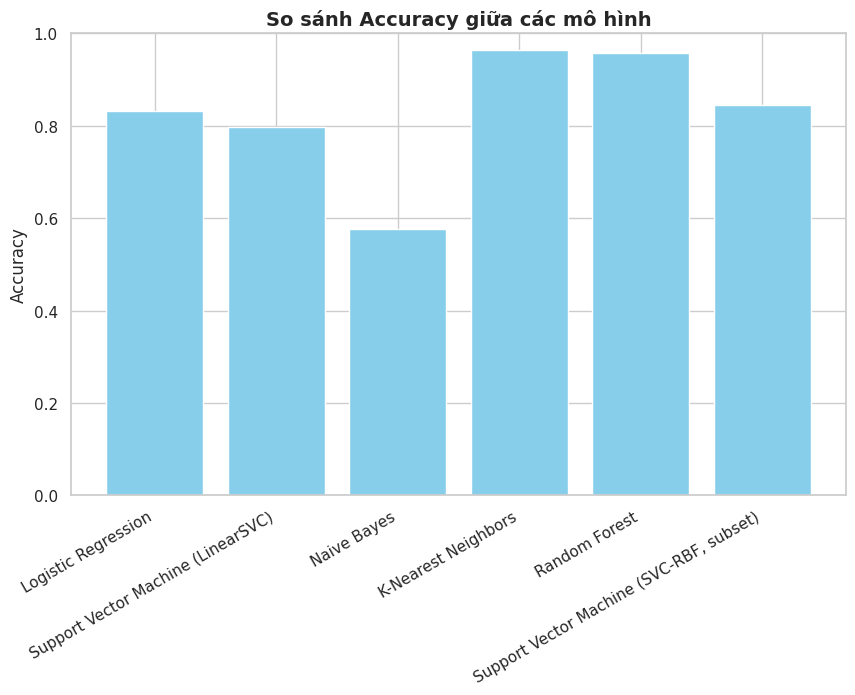

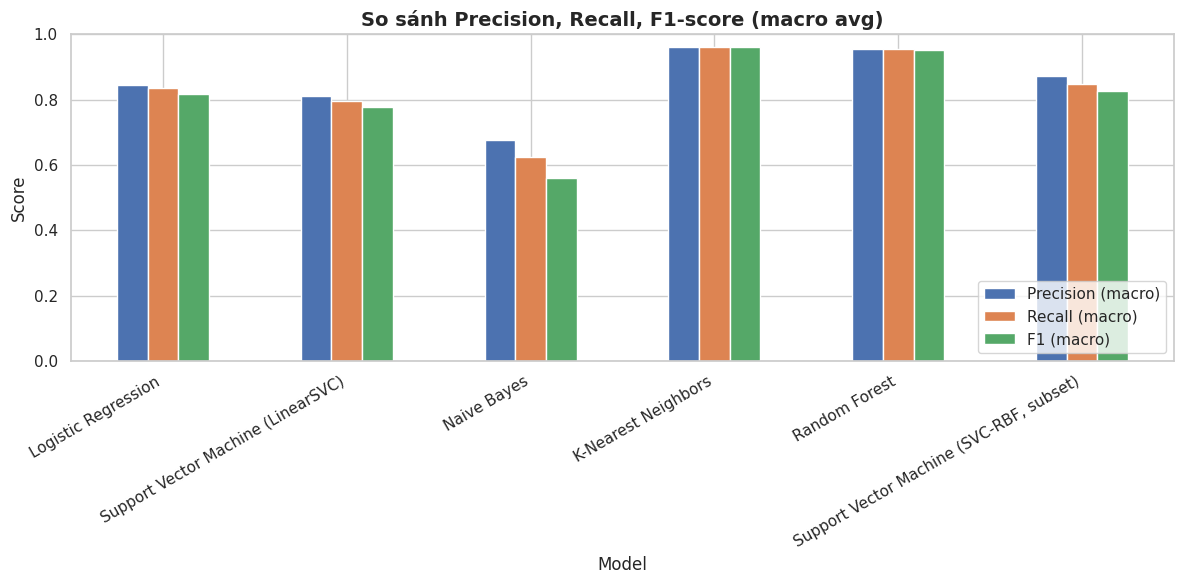

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

print("--- MODEL IMPLEMENTATION & COMPARISON ---")

# 1. Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Khởi tạo 5 mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=42),
    "Support Vector Machine (LinearSVC)": LinearSVC(max_iter=5000, random_state=42),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

subset_size = 100000
X_train_sub = X_train_scaled[:subset_size]
y_train_sub = y_train[:subset_size]
X_test_sub = X_test_scaled[:subset_size]
y_test_sub = y_test[:subset_size]

models_subset = {
    "Support Vector Machine (SVC-RBF, subset)": SVC(kernel="rbf", random_state=42)
}

# Lấy tên các nhãn chữ
label_names = le.classes_

# 3. Huấn luyện, đánh giá và lưu kết quả
results = []

def evaluate_model(name, model, Xtr, ytr, Xte, yte):
    print("==================================================")
    print(f"[*] Đang huấn luyện: {name} ...")
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    print(f"\n[+] Classification Report - {name}:")
    report = classification_report(yte, y_pred, target_names=label_names, zero_division=0)
    print(report)

    report_dict = classification_report(yte, y_pred, target_names=label_names, output_dict=True, zero_division=0)
    results.append({
        "Model": name,
        "Accuracy": report_dict["accuracy"],
        "Precision (macro)": report_dict["macro avg"]["precision"],
        "Recall (macro)": report_dict["macro avg"]["recall"],
        "F1 (macro)": report_dict["macro avg"]["f1-score"]
    })

    cm = confusion_matrix(yte, y_pred)
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_names, yticklabels=label_names)
    plt.title(f'Confusion Matrix: {name}', fontsize=14, fontweight='bold')
    plt.ylabel('Thực tế (True Label)', fontsize=12)
    plt.xlabel('Dự đoán (Predicted Label)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

for name, model in models.items():
    evaluate_model(name, model, X_train_scaled, y_train, X_test_scaled, y_test)

for name, model in models_subset.items():
    evaluate_model(name, model, X_train_sub, y_train_sub, X_test_sub, y_test_sub)

# 4. So sánh kết quả 
df_results = pd.DataFrame(results)
print("\n=== Tổng hợp kết quả ===")
print(df_results)

# Biểu đồ Accuracy
plt.figure(figsize=(10,6))
plt.bar(df_results["Model"], df_results["Accuracy"], color="skyblue")
plt.title("So sánh Accuracy giữa các mô hình", fontsize=14, fontweight="bold")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.ylim(0,1)
plt.show()

# Biểu đồ nhóm Precision, Recall, F1
df_metrics = df_results.set_index("Model")[["Precision (macro)", "Recall (macro)", "F1 (macro)"]]
df_metrics.plot(kind="bar", figsize=(12,6))
plt.title("So sánh Precision, Recall, F1-score (macro avg)", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0,1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [11]:
import time
import datetime
import random
import pandas as pd
import joblib
import warnings

# Tắt cái cảnh báo lải nhải của sklearn cho output sạch đẹp
warnings.filterwarnings("ignore", category=UserWarning)

print("--- BEST MODEL DEPLOYMENT ---")

# 1. Lưu mô hình Random Forest ra file
best_model = models["Random Forest"]
joblib.dump(best_model, 'random_forest_ids.pkl')
print("[+] Đã lưu mô hình triển khai: random_forest_ids.pkl\n")

# 2. Xây dựng hàm mô phỏng (Real-time IDS Engine)
def simulate_suricata_ids(single_flow, model, le_classes):
    """
    Simulates receiving a single network flow input.
    Predicts using Random Forest and generates a Suricata-style alert if malicious.
    """

    prediction = model.predict(single_flow.values)[0]
    predicted_label = le_classes[prediction]
    
    if predicted_label != "BENIGN":
        timestamp = datetime.datetime.now().strftime("%m/%d/%Y-%H:%M:%S.%f")[:-3]
        sid = random.randint(2000000, 2099999)
        
        suricata_alert = (
            f"{timestamp}  [**] [1:{sid}:1] "
            f"IDS DETECT WARNING: {predicted_label} Traffic Detected [**] "
            f"[Classification: A Network Trojan/Attack was Detected] [Priority: 1] "
            f"{{TCP}} External_IP:Any -> Internal_Network:Any"
        )
        
        print(f"\033[91m{suricata_alert}\033[0m")
        
        with open("alerts.log", "a") as log_file:
            log_file.write(suricata_alert + "\n")
    else:
        pass 

# 3. Chạy vòng lặp mô phỏng thời gian thực
print("[*] Khởi động Suricata-style IDS Engine. Đang lắng nghe mạng...\n")

open("alerts.log", "w").close()

sample_size = 30
test_indices = random.sample(range(len(X_test)), sample_size)

attacks_caught = 0

for i, idx in enumerate(test_indices):
    single_input = X_test.iloc[[idx]]
    
    actual_label = label_names[y_test.iloc[idx]]
    if actual_label != "BENIGN":
        attacks_caught += 1
        
    time.sleep(0.2)
    simulate_suricata_ids(single_input, best_model, label_names)

print(f"\n[+] Phân tích hoàn tất {sample_size} gói tin.")
print(f"[+] Tạo log cho {attacks_caught} luồng tấn công.")
print("[+] Xuất file 'alerts.log'.")

--- BEST MODEL DEPLOYMENT ---
[+] Đã lưu mô hình triển khai: random_forest_ids.pkl

[*] Khởi động Suricata-style IDS Engine. Đang lắng nghe mạng...

05/01/2026-13:15:09.784  [**] [1:2027524:1] IDS DETECT WARNING: Heartbleed Traffic Detected [**] [Classification: A Network Trojan/Attack was Detected] [Priority: 1] {TCP} External_IP:Any -> Internal_Network:Any
05/01/2026-13:15:12.071  [**] [1:2030820:1] IDS DETECT WARNING: Heartbleed Traffic Detected [**] [Classification: A Network Trojan/Attack was Detected] [Priority: 1] {TCP} External_IP:Any -> Internal_Network:Any

[+] Phân tích hoàn tất 30 gói tin.
[+] Tạo log cho 20 luồng tấn công.
[+] Xuất file 'alerts.log'.
